# Threads:
- In an operating system, a thread is the smallest unit of execution within a process.

- A process can have one or more threads.

- All threads in the same process share the same memory space, files, and other resources.

- Each thread has its own stack, program counter, and registers.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/a5/Multithreaded_process.svg/1280px-Multithreaded_process.svg.png" width="300" />

**Key benefits:**

- Lightweight – faster to create and switch between than processes.

- Parallelism:
    - On single-core → concurrency (time-sliced)
    - On multi-core → true parallelism

<img src="abc.jpeg" width="400" />


- Example: In a web browser, one thread loads a web page while another keeps the UI responsive.



# Pthreads (POSIX Threads) in C:
In C programming, Pthreads is the standard library for implementing multi-threading on Unix-like operating systems (Linux, macOS). While C doesn't have "built-in" threading in its oldest standards, the pthread.h library provides a powerful interface to create, manage, and synchronize concurrent execution flows within a single process.

**1. The Core Execution Model**
In a single-threaded program, there is one execution path (the main function). With Pthreads, you can spawn "peer" threads. Each thread has its own:

- Stack: For local variables and function calls.

- Registers & Program Counter: To track its current instruction.

However, all threads share the Heap, Global Variables, and File Descriptors.

# Example: Threads in Action !!!



```bash
PROCESS (1 process)
│
├── Main Thread:
│   ├── Creates t1
│   ├── Creates t2  
│   ├── Calls pthread_join(t1)  ← Waits, doesn't print
│   ├── Calls pthread_join(t2)  ← Waits, doesn't print
│   └── Returns 0
│
├── Thread t1:
│   ├── printf("Test")     ← PRINT #1
│   ├── sleep(3)
│   └── printf("Ending")   ← PRINT #2
│
└── Thread t2:
    ├── printf("Test")     ← PRINT #3
    ├── sleep(3)
    └── printf("Ending")   ← PRINT #4
```

In [5]:
%%bash
cat <<EOF > code.c
#include <stdlib.h>   // Standard library - for memory allocation, conversions, etc.
#include <stdio.h>     // Standard I/O - for printf()
#include <unistd.h>    // UNIX standard - for sleep()
#include <pthread.h>   // POSIX threads - for thread creation/management
void* routine()
{
    printf("\nTest from threads\n");
    sleep(3);
    printf("\nEnding thread\n");
}

int main(int argc, char* argv[])
{

    // You are already in a thread right from the start!
   
   printf("This is running on the main thread\n");
   
   
   pthread_t t1,t2;



if (pthread_create(&t1,NULL, &routine, NULL) !=0)
    {
        return 1;
    }




    if (pthread_create(&t2,NULL, &routine, NULL) !=0 )
    {
        return 2;
    }
    
    if (pthread_join(t1,NULL) !=0 ) //  "Join t1 into main"
    {
        return 3;
    }
    
    if (pthread_join(t2,NULL) !=0)
    {return 4;}
    return 0;

}

EOF

gcc code.c -o code
./code

This is running on the main thread

Test from threads

Test from threads

Ending thread

Ending thread


# pthread_create(&t1, NULL, &routine, NULL)
This is a function call that asks the OS to create a new thread.:

&t1-------"Store the new thread's ID in variable t1" (passing address so function can modify it)


NULL-----"Use default thread attributes" (stack size, scheduling policy, etc.)

&routine--------	"Start executing the function called routine" (passing function pointer)


NULL------"Don't pass any arguments to the routine function"

```bash
Thread t1: ┌─────────────────────────┐
           │ Print "Test" (1st time) │
           │ Sleep 3 seconds         │
           │ Print "Ending"(1st time)│
           └─────────────────────────┘

Thread t2: ┌─────────────────────────┐
           │ Print "Test" (2nd time) │
           │ Sleep 3 seconds         │
           │ Print "Ending"(2nd time)│
           └─────────────────────────┘

Output:
Test from threads    ← from t1
Test from threads    ← from t2
Ending thread        ← from t1 (or t2)
Ending thread        ← from t2 (or t1)
```

# Exmple: Threads share memory

In [6]:
%%bash
cat <<EOF > code.c
#include <stdio.h>
#include <pthread.h>
#include <unistd.h>

// Global variable - shared between threads
int x = 0;

// Thread t1: increments x and prints it











void* func1(void* arg) {
    
        x++;  // Increment global variable
        printf("Thread t1: x = %d (incremented)\n", x);
        sleep(2);  // Small delay to make output readable
    
    return NULL;
}

// Thread t2: just reads and prints x



void* func2(void* arg) {
        printf("Thread t2: x = %d (just reading)\n", x);
        sleep(2);  // Same delay to sync with t1
    
    return NULL;
}

int main() {
    pthread_t t1, t2;
    
    printf("Starting threads...\n");
    printf("Initial value of x = %d\n\n", x);
    
    // Create both threads
    pthread_create(&t1, NULL, func1, NULL);
    pthread_create(&t2, NULL, func2, NULL);
    
    // Wait for both threads to finish
    pthread_join(t1, NULL);
    pthread_join(t2, NULL);
    
    printf("\nFinal value of x = %d\n", x);
    printf("Both threads finished!\n");
    
    return 0;
}
EOF

gcc code.c -o code
./code

Starting threads...
Initial value of x = 0

Thread t1: x = 1 (incremented)
Thread t2: x = 1 (just reading)

Final value of x = 1
Both threads finished!


# Race Condition



When multiple threads take turns executing small pieces of their work in a mixed, overlapping order. They don’t run strictly one after the other, instead their instructions get mixed together.

In [8]:
%%bash
cat <<EOF > code.c

#include <stdio.h>
#include <pthread.h>

// Shared global variable
int counter = 0;
int loop_end = 1000000;


void* increment(void* arg) {
    
    for (int i = 0; i < loop_end; i++) {
        counter++;  // RACE CONDITION HERE!
    }
    return NULL;
}

int main() {
    pthread_t t1, t2;
    
    // Create two threads both incrementing counter
    pthread_create(&t1, NULL, increment, NULL);
    pthread_create(&t2, NULL, increment, NULL);
    
    // Wait for both to finish
    pthread_join(t1, NULL);
    pthread_join(t2, NULL);
    
    printf("Expected: %d\n",loop_end*2);
    printf("Actual:   %d\n", counter);
    
    return 0;
}

EOF
gcc code.c -o code
./code

Expected: 2000000
Actual:   998779




==========================================================



<b>`counter++;`</b> is not atomic, it happens in three steps internally:

- Read current value of counter
- Add 1
- Write it back

Lets  look at the following loop:

int counter = 0;
for (int i = 1; i <= 5; i++) {
  
  counter++;

}


so lets say during counter++, T1 hasn't written yet that T2 reads so both end up writing same value instead of two different values.

## The Race Condition Step-by-Step
## Case 1: Sequential Execution (What we WANT to happen)

**Thread 1 finishes completely, then Thread 2 runs**

| Step | Thread 1 | Thread 2 | `counter` value |
|------|----------|----------|-----------------|
| 1 | Reads 0 → adds 1 → writes 1 | | 1 |
| 2 | Reads 1 → adds 1 → writes 2 | | 2 |
| 3 | Reads 2 → adds 1 → writes 3 | | 3 |
| 4 | Reads 3 → adds 1 → writes 4 | | 4 |
| 5 | Reads 4 → adds 1 → writes 5 | | 5 |
| 6 | | Reads 5 → adds 1 → writes 6 | 6 |
| 7 | | Reads 6 → adds 1 → writes 7 | 7 |
| 8 | | Reads 7 → adds 1 → writes 8 | 8 |
| 9 | | Reads 8 → adds 1 → writes 9 | 9 |
| 10 | | Reads 9 → adds 1 → writes 10 | 10 |

**Expected final counter: 10** 

> Both threads ran. Each incremented 5 times. Total = 10 increments.

---

## Case 2: Race Condition (What ACTUALLY happens)

**Threads run at the same time. CPU switches between them unpredictably.**

Here's what happens when both threads read the **same initial value**:

| Step | Thread 1 | Thread 2 | `counter` value |
|------|----------|----------|-----------------|
| 1 | Reads 0 | | 0 |
| 2 | | Reads 0 | 0 |
| 3 | Adds 1 → gets 1 | | 0 |
| 4 | | Adds 1 → gets 1 | 0 |
| 5 | Writes 1 | | 1 |
| 6 | | Writes 1 | 1 |
| 7 | Reads 1 | | 1 |
| 8 | Adds 1 → gets 2 | | 1 |
| 9 | Writes 2 | | 2 |
| 10 | | Reads 2 | 2 |
| 11 | | Adds 1 → gets 3 | 2 |
| 12 | | Writes 3 | 3 |
| 13 | Reads 3 | | 3 |
| 14 | Adds 1 → gets 4 | | 3 |
| 15 | Writes 4 | | 4 |
| 16 | | Reads 4 | 4 |
| 17 | | Adds 1 → gets 5 | 4 |
| 18 | | Writes 5 | 5 |
| ... | ... | ... | ... |

---

### Look at Steps 1-6 carefully:

| Step | Thread 1 | Thread 2 | `counter` value |
|------|----------|----------|-----------------|
| 1 | Reads 0 | | 0 |
| 2 | | Reads 0 | 0 |
| 3 | Adds 1 → gets 1 | | 0 |
| 4 | | Adds 1 → gets 1 | 0 |
| 5 | Writes 1 | | 1 |
| 6 | | Writes 1 | 1 |

**Two increments happened, but `counter` increased by only 1!**

📉 **One update was LOST.**

# Mutex
A mutex (short for mutual exclusion) is a synchronization primitive used in concurrent programming to prevent race conditions. Think of it as a lock that ensures only one thread at a time can access a critical section of code (like counter++).


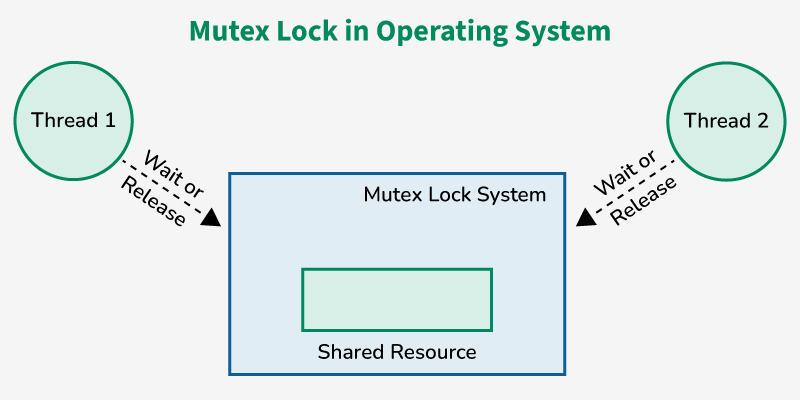

In [27]:
%%bash
cat <<EOF > code_fixed.c

#include <stdio.h>
#include <pthread.h>

// Shared global variable
int counter = 0;
int loop_end = 1000000;



// Mutex (mutual exclusion lock)
pthread_mutex_t lock;

void* increment(void* arg) {
    for (int i = 0; i < loop_end; i++) {
        pthread_mutex_lock(&lock);   // LOCK - only one thread enters
        counter++;                    // Critical section (now safe!)
        pthread_mutex_unlock(&lock); // UNLOCK - let others in
    }
    return NULL;
}

int main() {
    pthread_t t1, t2;
    
    // Initialize the mutex
    pthread_mutex_init(&lock, NULL);
    
    // Create two threads both incrementing counter
    pthread_create(&t1, NULL, increment, NULL);
    pthread_create(&t2, NULL, increment, NULL);
    
    // Wait for both to finish
    pthread_join(t1, NULL);
    pthread_join(t2, NULL);
    
    // Destroy the mutex (cleanup)
    pthread_mutex_destroy(&lock);
    
    printf("Expected: %d\n", loop_end * 2);
    printf("Actual:   %d\n", counter);
    
    return 0;
}

EOF

gcc code_fixed.c -o code_fixed -pthread
./code_fixed

Expected: 2000000
Actual:   2000000


# Checking CPU physical cores:
---------------------------    

```bash


    
# Get the number of CPU cores available (for thread creation)        


nproc


# Get detailed CPU info including cores and threads


lscpu | grep -E "^CPU\(s\)|^Thread|^Core|^Socket|^Model name"






```

In [31]:
%%bash
cat <<EOF > code_fixed.c

#include <stdio.h>
#include <pthread.h>
#include <stdio.h>
#include <pthread.h>
#include <unistd.h>

void* busy_work(void* arg) {
    int id = *(int*)arg;
    printf("Thread %d starting on core\n", id);
    
    // Spin forever (100% CPU usage)
    while(1) {
        // Keep CPU busy
    }
    return NULL;
}

int main() {
    pthread_t threads[8];
    int ids[4] = {0,1,2,3,4,5,6,7};
    
    // Create 4 threads
    for(int i = 0; i <8 ; i++) {
        pthread_create(&threads[i], NULL, busy_work, &ids[i]);
    }
    
    // Run htop in another terminal
    // You will see cores at 100%
    
    pthread_join(threads[0], NULL);
    return 0;
}

EOF

gcc code_fixed.c -o code_fixed -pthread
./code_fixed

Process is interrupted.


# Creating threads with loops
- Always use one loop for creating threads and another to join in order to achieve parallelism.

- If threads are created and joined in a single loop then they run sequentially and there is no parallelism

In [25]:
%%bash
####################### Single Loop ######################

cat <<EOF > code.c
#include <stdio.h>
#include <pthread.h>
#include <unistd.h>

void* work(void* arg) {
    int id = *(int*)arg;
    printf("Thread %d: STARTED\n", id);
    sleep(1);  // simulate work
    printf("Thread %d: FINISHED\n", id);
    return NULL;
}

int main() {
    pthread_t threads[3];
    int ids[3] = {0,1,2};

    // Create + join in same loop
    for (int i = 0; i < 3; i++) {
        pthread_create(&threads[i], NULL, work, &ids[i]);
        pthread_join(threads[i], NULL);  // waits immediately
    }

    printf("All done (sequential)\n");
    return 0;
}


EOF

gcc code.c -o code 
./code


Thread 0: STARTED
Thread 0: FINISHED
Thread 1: STARTED
Thread 1: FINISHED
Thread 2: STARTED
Thread 2: FINISHED
All done (sequential)


In [26]:
%%bash
####################### Multiple Loops ######################

cat <<EOF > code.c

#include <stdio.h>
#include <pthread.h>
#include <unistd.h>

void* work(void* arg) {
    int id = *(int*)arg;
    printf("Thread %d: STARTED\n", id);
    sleep(1);  // simulate work
    printf("Thread %d: FINISHED\n", id);
    return NULL;
}

int main() {
    pthread_t threads[3];
    int ids[3] = {0,1,2};

    // First loop: create all threads
    for (int i = 0; i < 3; i++) {
        pthread_create(&threads[i], NULL, work, &ids[i]);
    }

    // Second loop: join all threads
    for (int i = 0; i < 3; i++) {
        pthread_join(threads[i], NULL);
    }

    printf("All done (parallel)\n");
    return 0;
}



EOF

gcc code.c -o code 
./code


Thread 0: STARTED
Thread 1: STARTED
Thread 2: STARTED
Thread 1: FINISHED
Thread 2: FINISHED
Thread 0: FINISHED
All done (parallel)


# Passing value from a thread to main thread
User defined thread computes the sum. The value is passed to the main thread

In [28]:
%%bash

cat <<EOF > code.c

#include <stdio.h>
#include <pthread.h>
#include <stdlib.h>

// Thread function: compute sum of first N integers
void* compute_sum(void* arg) {


//For thread start routines (functions passed to pthread_create), the signature must be:
//void* compute_sum(void* arg)
//input: void* (generic pointer)
//output: void* (generic pointer)
//So we can pass anything by casting.
 
    
    int n = *(int*)arg;
    
    
//arg is a void*
//cast → (int*)
//dereference → get actual value
//So if arg = &n, this gives you the integer n    
    


//Threads don’t return values like normal functions. So we do this:
   
   
   int* result = malloc(sizeof(int));  // allocate memory for return value


//Why malloc?
//Because:
//Local variables disappear after the thread exits
//If we returned &local_var → dangling pointer (BUG)
//So we allocate on the heap → persists after thread ends

    *result = 0;
    for (int i = 1; i <= n; i++) {
        *result += i;
    }
    printf("Thread: computed sum up to %d = %d\n", n, *result);
    return result;  // return pointer to result
}




int main() {
    pthread_t thread;
    int n = 5;
    int* sum;

    // Create thread
    pthread_create(&thread, NULL, compute_sum, &n); //&n → argument passed to thread

    // Join thread and collect result
    pthread_join(thread, (void**)&sum);


//Why void**? Because:
//The thread returns a void* (a pointer)
//To return that pointer to us, pthread_join needs a pointer to where to store that pointer


    printf("Main: got result from thread = %d\n", *sum);

    free(sum);  // free allocated memory
    return 0;
}


EOF

gcc code.c -o code 
./code



Thread: computed sum up to 5 = 15
Main: got result from thread = 15


In [30]:
%%bash

cat <<EOF > code.c

#include <stdio.h>
#include <pthread.h>
#include <stdlib.h>

// Thread function: compute sum of first N integers
void* compute_sum(void* arg) {
    int n = *(int*)arg;
    int* result = malloc(sizeof(int));
    *result = 0;
    
    for (int i = 1; i <= n; i++) {
        *result += i;
    }
    
    printf("Thread: computed sum up to %d = %d\n", n, *result);
    return result;
}

int main() {
    pthread_t thread;
    int n = 5;
    int* sum;
    
    // Create thread
    pthread_create(&thread, NULL, compute_sum, &n);
    
    // Join thread and collect result
    pthread_join(thread, (void**)&sum);
    
    printf("Main: got result from thread = %d\n", *sum);
    
    free(sum);
    return 0;
}


EOF

gcc code.c -o code 
./code

Thread: computed sum up to 5 = 15
Main: got result from thread = 15


# Explanation of above code
## Understanding the Code: Thread Communication

### What This Code Does
A child thread computes the sum of 1 to 5, then passes the result back to the main thread.

### The Flow

| Step | Thread | Action |
|------|--------|--------|
| 1 | Main | Creates child thread, passes n=5 |
| 2 | Child | Computes sum (1+2+3+4+5 = 15) |
| 3 | Child | Stores result on heap using malloc() |
| 4 | Child | Returns pointer to main thread |
| 5 | Main | Waits for child with pthread_join() |
| 6 | Main | Receives pointer, prints 15 |
| 7 | Main | Frees memory with free() |

### Key Concepts Explained

#### 1. void* compute_sum(void* arg)
- Fixed signature required by pthread_create()
- void* = generic pointer (can point to any data type)

#### 2. `int n = *(int*)arg;`
- Cast void* to int* (pointer to integer)
- Dereference * to get actual value

#### 3. int* result = malloc(sizeof(int));
Why heap allocation?
- Local variables vanish when thread exits (WRONG)
- Heap memory persists after thread dies (CORRECT)
- Without malloc: dangling pointer -> crash

#### 4. return result;
- Returns a pointer (memory address), not the value
- Main thread receives this address

#### 5. pthread_join(thread, (void**)&sum);
- First argument: Thread to wait for
- Second argument: Where to store returned pointer
- `(void**)&sum = cast int** to void**` (required by pthread)

#### 6. free(sum);
- CRITICAL: Prevents memory leak
- Heap memory must be explicitly freed

### Common Mistakes to Avoid

| Mistake | Consequence |
|---------|-------------|
| Returning &local_var | Dangling pointer, undefined behavior |
| Forgetting free(sum) | Memory leak |
| Dereferencing sum before join | Using incomplete data |
| Wrong cast in pthread_join | Compiler warning or crash |

### Sample Output
Thread: computed sum up to 5 = 15
Main: got result from thread = 15